# ResNet-18 (Naive — Frozen Backbone)

In [1]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv('data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Positive weight: tensor([8.1117], device='cuda:0')


In [5]:
best_val_f2 = 0.0
num_epochs = 20
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), 'models/resnet_naive_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.8237, Bal Acc: 0.7752, Recall: 0.8312, F2: 0.5846 | Val Loss: 0.8165, Bal Acc: 0.7939, Recall: 0.8517, F2: 0.6215
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.6467, Bal Acc: 0.8321, Recall: 0.8655, F2: 0.6660 | Val Loss: 0.7537, Bal Acc: 0.7944, Recall: 0.8136, F2: 0.6242
Saved best model at epoch 2


Epoch [3/20] | Train Loss: 0.5357, Bal Acc: 0.8716, Recall: 0.9054, F2: 0.7278 | Val Loss: 0.8625, Bal Acc: 0.7999, Recall: 0.7373, F2: 0.6378
Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.4906, Bal Acc: 0.8879, Recall: 0.9156, F2: 0.7567 | Val Loss: 1.4434, Bal Acc: 0.6966, Recall: 0.4407, F2: 0.4590


Epoch [5/20] | Train Loss: 0.4235, Bal Acc: 0.9042, Recall: 0.9270, F2: 0.7870 | Val Loss: 0.8647, Bal Acc: 0.7866, Recall: 0.7415, F2: 0.6162


...

Epoch [16/20] | Train Loss: 0.1279, Bal Acc: 0.9736, Recall: 0.9783, F2: 0.9350 | Val Loss: 1.2635, Bal Acc: 0.8167, Recall: 0.7754, F2: 0.6626


Epoch [17/20] | Train Loss: 0.1441, Bal Acc: 0.9722, Recall: 0.9783, F2: 0.9310 | Val Loss: 1.1946, Bal Acc: 0.7793, Recall: 0.6737, F2: 0.6073


Epoch [18/20] | Train Loss: 0.1300, Bal Acc: 0.9750, Recall: 0.9806, F2: 0.9376 | Val Loss: 2.1745, Bal Acc: 0.7389, Recall: 0.5254, F2: 0.5377


Epoch [19/20] | Train Loss: 0.1555, Bal Acc: 0.9653, Recall: 0.9681, F2: 0.9180 | Val Loss: 1.3411, Bal Acc: 0.8004, Recall: 0.7161, F2: 0.6406


Epoch [20/20] | Train Loss: 0.1078, Bal Acc: 0.9774, Recall: 0.9795, F2: 0.9456 | Val Loss: 1.1348, Bal Acc: 0.8298, Recall: 0.8178, F2: 0.6796


## Training Curves

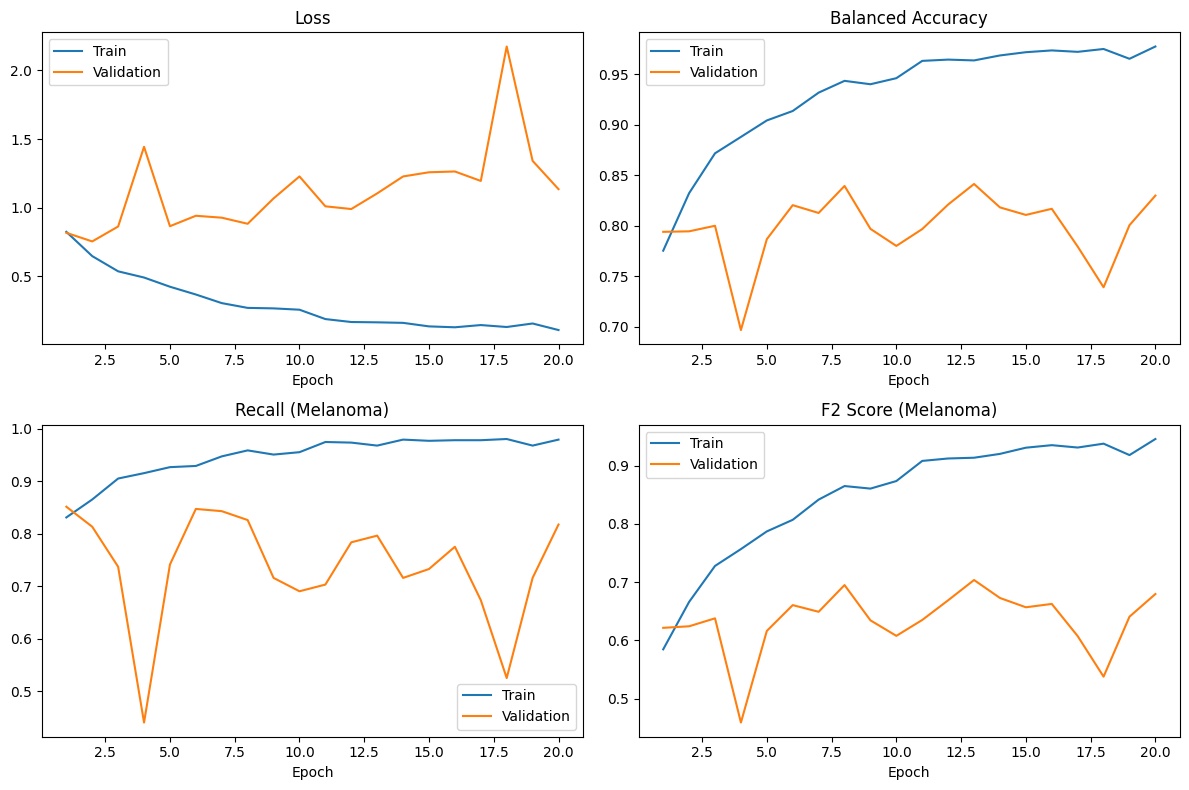

In [6]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [7]:
model.load_state_dict(torch.load('models/resnet_naive_best.pth', map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.47 | Val F2: 0.7068


Threshold:          0.47
AUC-ROC:            0.8900
Balanced Accuracy:  0.8019
F2 Score:           0.6409

              precision    recall  f1-score   support

Non-Melanoma     0.9600    0.8963    0.9271      1340
    Melanoma     0.4654    0.7076    0.5615       171

    accuracy                         0.8749      1511
   macro avg     0.7127    0.8019    0.7443      1511
weighted avg     0.9041    0.8749    0.8857      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


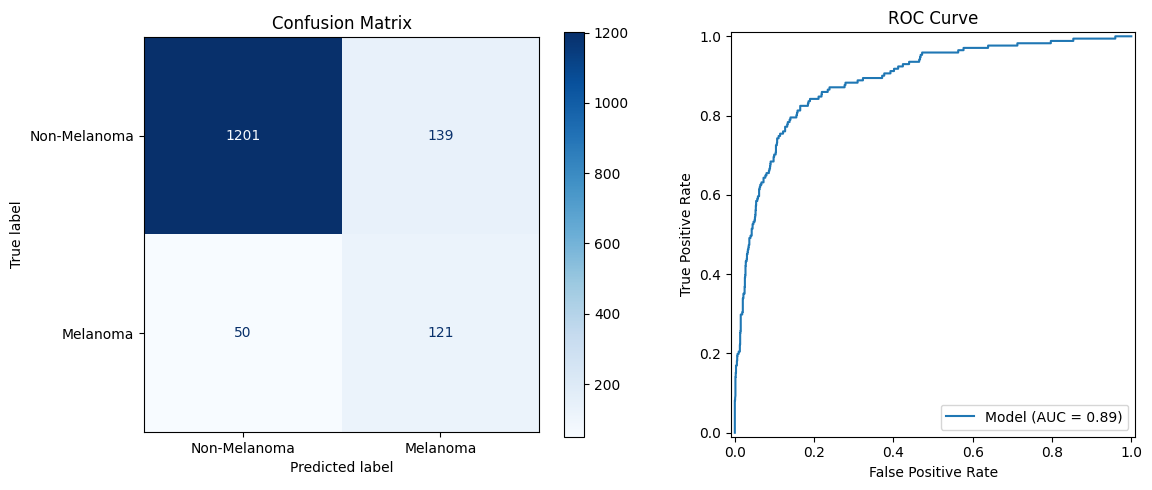

In [8]:
evaluate_model(model, test_loader, device, threshold=best_threshold)